In [2]:
# インストール
%pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# 必要なライブラリを読み込み
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path as path
from sklearn.linear_model import LinearRegression
from sklearn import set_config

set_config(display="text")

In [4]:
# CSVを読み込み
input_path =path("体重計記録_前処理済み.csv")

df = pd.read_csv(input_path)

In [5]:
# 体重と体脂肪率の相関関係を計算
correlation = df["体重 (kg)"].corr(df["体脂肪率 %"])

print(f"相関係数：{correlation:.3f}")


# 説明変数と目的変数を用意
X = df[["体重 (kg)"]]
y = df["体脂肪率 %"]

print()
print("Xの形：", X.shape)
print("yの形：", y.shape)


# 線形回帰モデルを作成して学習
model = LinearRegression()
model.fit(X, y)

相関係数：0.983

Xの形： (122, 1)
yの形： (122,)


LinearRegression()

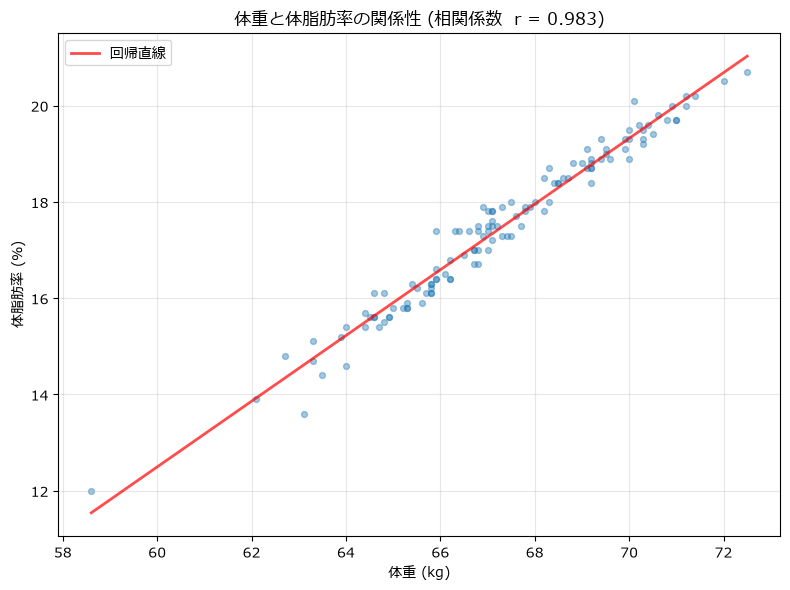

In [6]:
# 日本語の文字化けを防ぐ
plt.rcParams["font.family"] = "meiryo"


# 体重と体脂肪率の散布図
fig, ax = plt.subplots(figsize=(8,6))

ax.scatter(
    df["体重 (kg)"],   #横軸
    df["体脂肪率 %"],  #縦軸
    s=18,             #点のサイズ
    alpha=0.4
)


# 回帰直線用の予測値を作成
X_line = X.sort_values("体重 (kg)")
y_pred = model.predict(X_line)


# 回帰直線
ax.plot(
    X_line["体重 (kg)"],
    y_pred,
    color="red",
    linewidth=2,
    label="回帰直線",
    alpha=0.7
)


ax.set_title(
    f"体重と体脂肪率の関係性 (相関係数  r = {correlation:.3f})"
)

ax.set_xlabel("体重 (kg)")
ax.set_ylabel("体脂肪率 (%)")

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()